In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense , Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
X_train=np.load('../data/X_train.npy')
X_test=np.load('../data/X_test.npy')
y_train=np.load('../data/y_train.npy')
y_test=np.load('../data/y_test.npy')

print("X_Train shape:", X_train.shape)
print("X_test Shape: ",X_test.shape)

X_Train shape: (958, 60, 1)
X_test Shape:  (240, 60, 1)


In [3]:
# MODEL BUILDING

model = Sequential([

  LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)),
  #Second LSTM layer
  LSTM(64,return_sequences=False),
  Dropout(0.2),

  # Output layer - predicts a single value
  Dense(1)
])

model.summary()

c:\Users\ABHISHEK KUMAR\OneDrive\Desktop\Stock-Predictor\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
  optimizer='adam',
  loss='mean_squared_error'
)

In [5]:
callbacks=[
  EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
  ),

  ModelCheckpoint(
    filepath='../models/best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
  )
]

In [6]:
history=model.fit(
  X_train,y_train,
  epochs=50,
  batch_size=32,
  validation_split=0.1,
  callbacks=callbacks,
  verbose=1
)

Epoch 1/50
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0982
Epoch 1: val_loss improved from None to 0.00530, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0404 - val_loss: 0.0053
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0064
Epoch 2: val_loss improved from 0.00530 to 0.00141, saving model to ../models/best_model.keras

Epoch 2: finished saving model to ../models/best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0048 - val_loss: 0.0014
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0031
Epoch 3: val_loss did not improve from 0.00141
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0029
Epoch 4: val_loss did not improve from 0.00141
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━

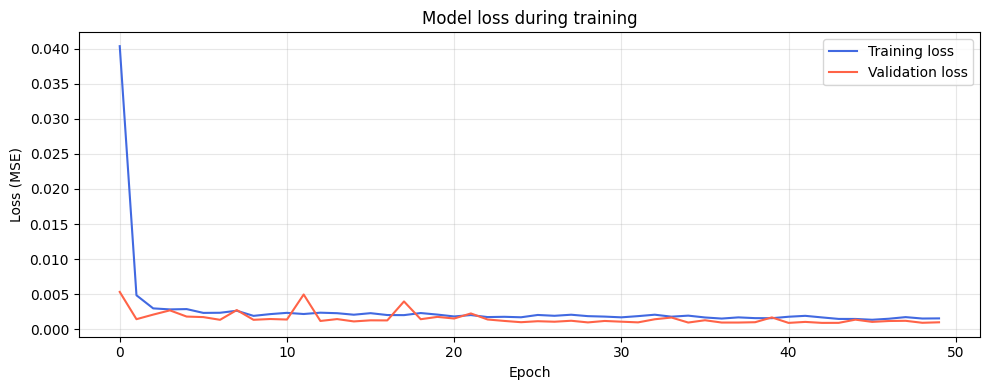

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10 , 4))
plt.plot(history.history['loss'],  label='Training loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Validation loss', color='tomato')
plt.title('Model loss during training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()